# Cross-Dataset Results
Compares **SFT baseline**, **EWL**, and **EWL (no grad proxy)** across four FGVC datasets.

All conditions: rank=4, α=0.9, τ=1.0 · Seeds {11, 22, 33} · mean ± std.

In [1]:
import re, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 1200,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.framealpha": 0.9,
    "legend.fontsize": 9,
})

C = {
    "baseline":     "#D6604D",   # muted red
    "ewl":          "#2166AC",   # steel blue
    "ewl_no_proxy": "#4DAC26",   # muted green
}

BASE_DIR = Path("../outputs/vision/all_datasets")
DATASETS  = ["aircraft", "cub200", "stanford_dogs"]#, "food101"]
SEEDS     = [11, 22, 33]
CONDITIONS = ["baseline", "ewl", "ewl_no_proxy"]

_DIR_RE = re.compile(r"^(baseline|ewl_no_proxy|ewl)_s(\d+)$")

def load_all(base=BASE_DIR, seeds=SEEDS):
    rows = []
    for ds in DATASETS:
        ds_dir = base / ds
        if not ds_dir.exists():
            continue
        for d in sorted(ds_dir.iterdir()):
            if not d.is_dir(): continue
            m = _DIR_RE.match(d.name)
            if not m: continue
            cond, seed = m[1], int(m[2])
            if seed not in seeds: continue
            jsons = sorted(d.glob("results_*.json"))
            if not jsons: continue
            with open(jsons[-1]) as f:
                payload = json.load(f)
            rows.append({
                "dataset":   ds,
                "condition": cond,
                "seed":      seed,
                "test_acc":  payload.get("test_acc"),
                "test_f1":   payload.get("test_f1"),
                "test_loss": payload.get("test_loss"),
                "history":   payload.get("history", []),
            })
    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} runs across {df['dataset'].nunique()} datasets")
    return df

df = load_all()
df.drop(columns="history").sort_values(["dataset","condition","seed"])

Loaded 27 runs across 3 datasets


,dataset,condition,seed,test_acc,test_f1,test_loss
0,aircraft,baseline,11,0.581458,0.580436,1.514982
1,aircraft,baseline,22,0.590759,0.591513,1.501158
2,aircraft,baseline,33,0.595860,0.595272,1.484679
6,aircraft,ewl,11,0.579958,0.579798,1.561070
7,aircraft,ewl,22,0.593459,0.593488,1.545093
8,aircraft,ewl,33,0.596160,0.596807,1.528564
3,aircraft,ewl_no_proxy,11,0.517252,0.518334,2.165387
4,aircraft,ewl_no_proxy,22,0.519652,0.514380,2.107791
5,aircraft,ewl_no_proxy,33,0.528353,0.527588,2.012349
9,cub200,baseline,11,0.862962,0.862070,0.568969


## Summary Table
mean ± std test accuracy across seeds.

In [2]:
COND_LABELS = {
    "baseline":     "SFT baseline",
    "ewl":          "EWL",
    "ewl_no_proxy": "EWL (no proxy)",
}
DS_LABELS = {
    "aircraft":      "FGVC-Aircraft",
    "cub200":        "CUB-200",
    "stanford_dogs": "Stanford Dogs",
    # "food101":       "Food-101",
}

table_rows = []
for ds in DATASETS:
    row = {"Dataset": DS_LABELS.get(ds, ds)}
    for cond in CONDITIONS:
        vals = df[(df.dataset == ds) & (df.condition == cond)]["test_acc"].dropna()
        if len(vals):
            row[COND_LABELS[cond]] = f"{vals.mean():.4f} ± {vals.std():.4f}"
            row[f"_n_{cond}"] = len(vals)
        else:
            row[COND_LABELS[cond]] = "—"
            row[f"_n_{cond}"] = 0
    # Delta columns
    for cond in ["ewl", "ewl_no_proxy"]:
        base_vals = df[(df.dataset == ds) & (df.condition == "baseline")]["test_acc"].dropna()
        cond_vals = df[(df.dataset == ds) & (df.condition == cond)]["test_acc"].dropna()
        if len(base_vals) and len(cond_vals):
            delta = cond_vals.mean() - base_vals.mean()
            row[f"Δ {COND_LABELS[cond]}"] = f"{delta:+.4f}"
        else:
            row[f"Δ {COND_LABELS[cond]}"] = "—"
    table_rows.append(row)

display_cols = ["Dataset"] + list(COND_LABELS.values()) + [f"Δ {v}" for v in list(COND_LABELS.values())[1:]]
summary = pd.DataFrame(table_rows)[display_cols].set_index("Dataset")

# Highlight: colour positive deltas
def highlight_delta(val):
    if isinstance(val, str) and val.startswith("+"):
        return "color: #2166AC; font-weight: bold"
    if isinstance(val, str) and val.startswith("-"):
        return "color: #D6604D"
    return ""

summary.style.applymap(highlight_delta, subset=[c for c in summary.columns if c.startswith("Δ")])

/tmp/ipykernel_3537244/644984895.py:46: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  summary.style.applymap(highlight_delta, subset=[c for c in summary.columns if c.startswith("Δ")])


,SFT baseline,EWL,EWL (no proxy),Δ EWL,Δ EWL (no proxy)
Dataset,,,,,
FGVC-Aircraft,0.5894 ± 0.0073,0.5899 ± 0.0087,0.5218 ± 0.0058,+0.0005,-0.0676
CUB-200,0.8615 ± 0.0035,0.8630 ± 0.0051,0.8597 ± 0.0049,+0.0016,-0.0018
Stanford Dogs,0.8943 ± 0.0006,0.8941 ± 0.0007,0.8889 ± 0.0030,-0.0001,-0.0054


## Figure — Test accuracy comparison across datasets

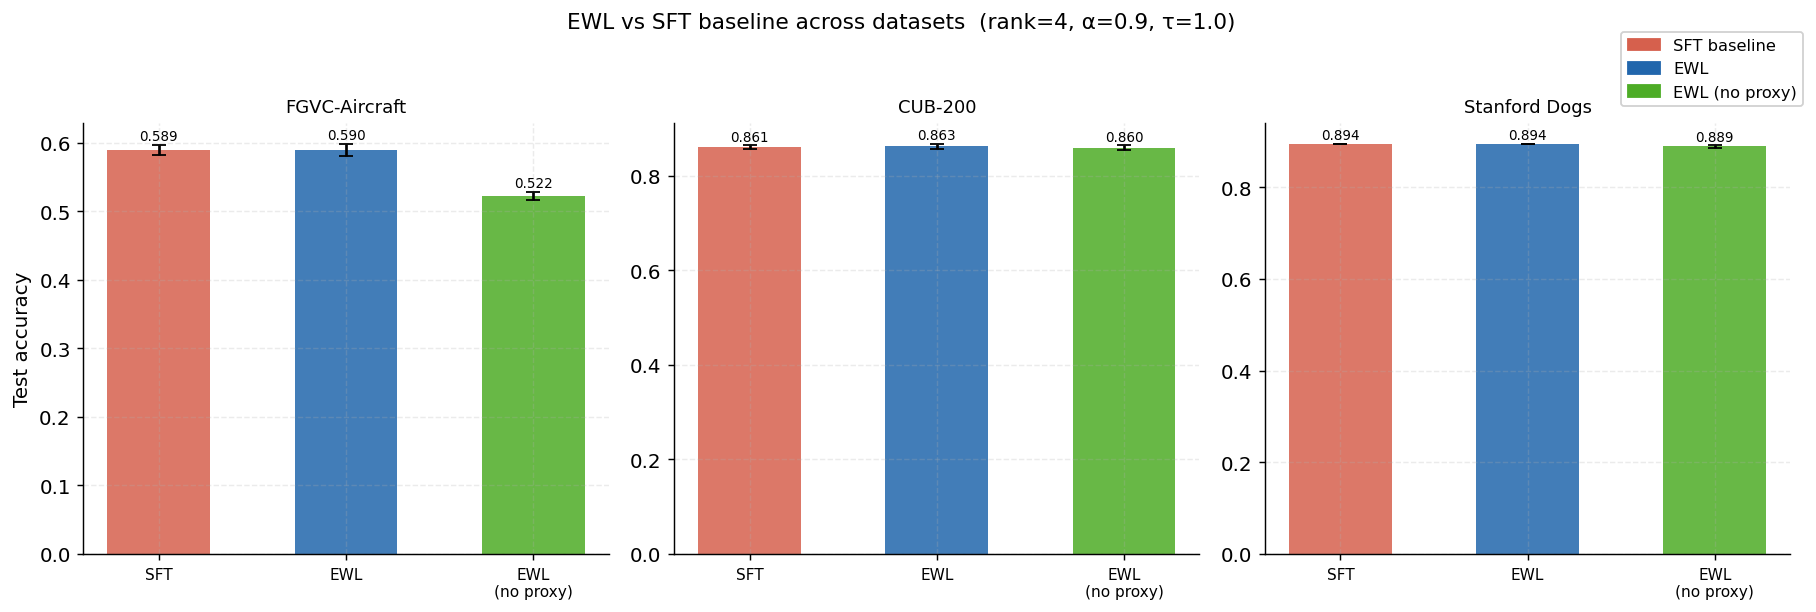

In [3]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(14, 4.5), sharey=False)

xs = np.arange(len(CONDITIONS))
w  = 0.55
labels = [COND_LABELS[c] for c in CONDITIONS]

for ax, ds in zip(axes, DATASETS):
    means, stds = [], []
    for cond in CONDITIONS:
        vals = df[(df.dataset == ds) & (df.condition == cond)]["test_acc"].dropna()
        means.append(vals.mean() if len(vals) else np.nan)
        stds.append(vals.std()  if len(vals) else 0.0)

    bars = ax.bar(xs, means, w, yerr=stds, capsize=4,
                  color=[C[c] for c in CONDITIONS], alpha=0.85)
    for bar, mu, sd in zip(bars, means, stds):
        if not np.isnan(mu):
            ax.text(bar.get_x() + bar.get_width()/2, mu + sd + 0.003,
                    f"{mu:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(xs)
    ax.set_xticklabels(["SFT", "EWL", "EWL\n(no proxy)"], fontsize=8.5)
    ax.set_title(DS_LABELS.get(ds, ds), fontsize=10)
    ax.set_ylabel("Test accuracy" if ds == DATASETS[0] else "")

# Shared legend
from matplotlib.patches import Patch
legend_el = [Patch(color=C[c], label=COND_LABELS[c]) for c in CONDITIONS]
fig.legend(handles=legend_el, loc="upper right", bbox_to_anchor=(1.0, 1.02), fontsize=9)

plt.suptitle("EWL vs SFT baseline across datasets  (rank=4, α=0.9, τ=1.0)",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig("fig_all_datasets.pdf", bbox_inches="tight", dpi=1200)
plt.show()

## Figure — Learning curves (best config per dataset)

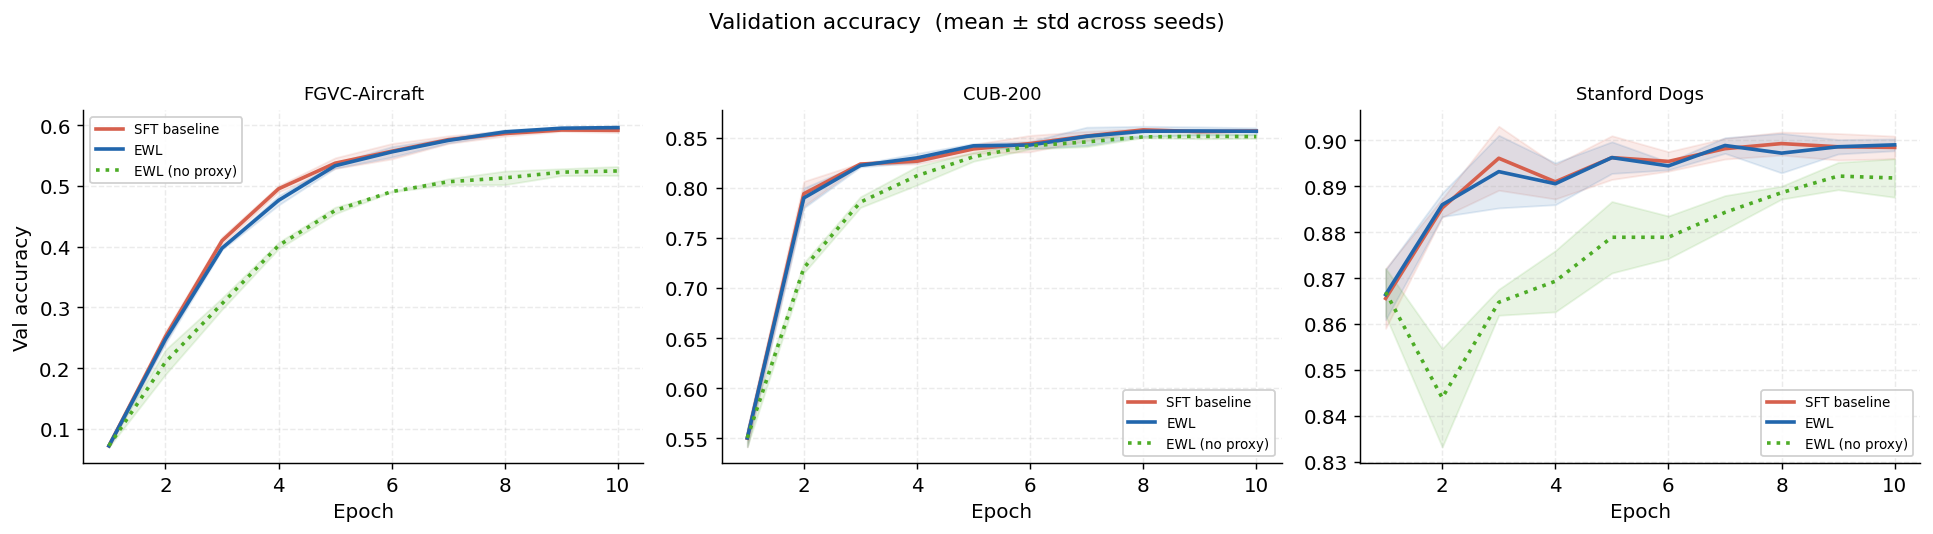

In [4]:
def get_curves(subset, metric="val_acc"):
    series = []
    for _, row in subset.iterrows():
        vals = [ep[metric] for ep in row["history"] if ep.get(metric) is not None]
        if vals: series.append(vals)
    if not series: return [], [], []
    min_len = min(len(s) for s in series)
    arr = np.array([s[:min_len] for s in series])
    return np.arange(1, min_len + 1), arr.mean(0), arr.std(0)

fig, axes = plt.subplots(1, len(DATASETS), figsize=(15, 4), sharey=False)

for ax, ds in zip(axes, DATASETS):
    for cond in CONDITIONS:
        sub = df[(df.dataset == ds) & (df.condition == cond)]
        ep, mu, sigma = get_curves(sub, "val_acc")
        if len(ep) == 0: continue
        ax.plot(ep, mu, color=C[cond], lw=2,
                ls="-" if cond != "ewl_no_proxy" else ":",
                label=COND_LABELS[cond])
        ax.fill_between(ep, mu - sigma, mu + sigma, color=C[cond], alpha=0.12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val accuracy" if ds == DATASETS[0] else "")
    ax.set_title(DS_LABELS.get(ds, ds), fontsize=10)
    ax.legend(fontsize=7.5)

plt.suptitle("Validation accuracy  (mean ± std across seeds)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig_all_datasets_curves.pdf", bbox_inches="tight", dpi=1200)
plt.show()

## Figure — System Metrics: VRAM and Throughput
Shows zero VRAM overhead of EWL vs SFT, and the 5.9× step-time cost.

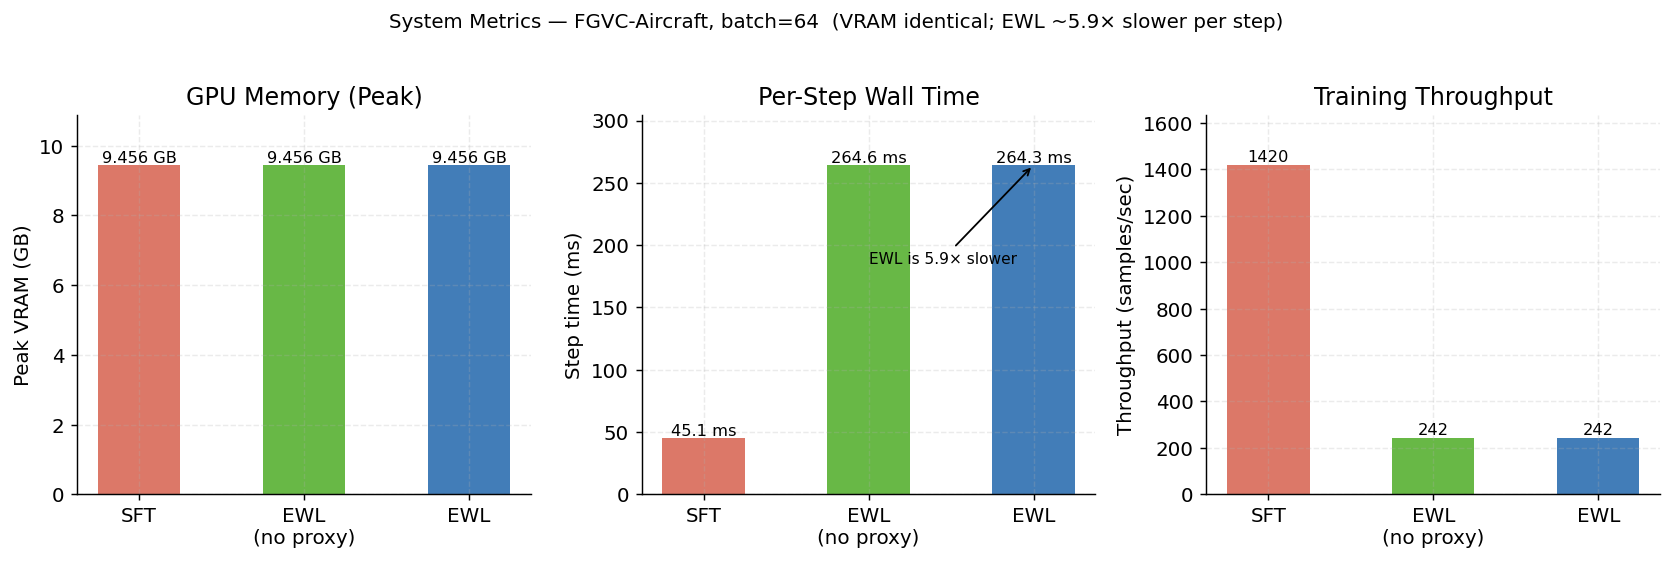

SFT step: 45.1 ms | EWL step: 264.3 ms | ratio: 5.9x


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import json, glob
from pathlib import Path

# Collect system metrics from aircraft all_datasets runs (last epoch)
metrics = {"lora_sft": {"vram": [], "step_ms": [], "tput": []},
           "ewl":      {"vram": [], "step_ms": [], "tput": []},
           "ewl_no_proxy": {"vram": [], "step_ms": [], "tput": []}}

for f in sorted(glob.glob("../outputs/vision/all_datasets/aircraft/**/*.json", recursive=True)):
    d = json.load(open(f))
    parts = Path(f).parts
    folder = parts[-2]
    if "no_proxy" in folder: cond = "ewl_no_proxy"
    elif folder.startswith("baseline"): cond = "lora_sft"
    else: cond = "ewl"
    if d.get("history"):
        ep = d["history"][-1]
        metrics[cond]["vram"].append(ep.get("peak_vram_gb", 0))
        metrics[cond]["step_ms"].append(ep.get("step_time_ms", 0))
        metrics[cond]["tput"].append(ep.get("throughput_samples_per_sec", 0))

COND_LABELS = {"lora_sft": "SFT", "ewl_no_proxy": "EWL\n(no proxy)", "ewl": "EWL"}
COLORS = {"lora_sft": "#D6604D", "ewl_no_proxy": "#4DAC26", "ewl": "#2166AC"}
conds = ["lora_sft", "ewl_no_proxy", "ewl"]
xs = np.arange(len(conds))
labels = [COND_LABELS[c] for c in conds]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

# Panel 1: VRAM
ax = axes[0]
means_v = [np.mean(metrics[c]["vram"]) for c in conds]
ax.bar(xs, means_v, color=[COLORS[c] for c in conds], alpha=0.85, width=0.5)
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylabel("Peak VRAM (GB)")
ax.set_title("GPU Memory (Peak)")
for i, v in enumerate(means_v):
    ax.text(i, v + 0.05, f"{v:.3f} GB", ha="center", fontsize=9)
ax.set_ylim(0, max(means_v) * 1.15)

# Panel 2: Step time
ax = axes[1]
means_s = [np.mean(metrics[c]["step_ms"]) for c in conds]
ax.bar(xs, means_s, color=[COLORS[c] for c in conds], alpha=0.85, width=0.5)
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylabel("Step time (ms)")
ax.set_title("Per-Step Wall Time")
for i, v in enumerate(means_s):
    ax.text(i, v + 2, f"{v:.1f} ms", ha="center", fontsize=9)
ax.set_ylim(0, max(means_s) * 1.15)
# Annotate speedup
sft_t = np.mean(metrics["lora_sft"]["step_ms"])
ewl_t = np.mean(metrics["ewl"]["step_ms"])
ax.annotate(f"EWL is {ewl_t/sft_t:.1f}× slower",
            xy=(2, ewl_t), xytext=(1.0, ewl_t * 0.7),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=8.5)

# Panel 3: Throughput
ax = axes[2]
means_t = [np.mean(metrics[c]["tput"]) for c in conds]
ax.bar(xs, means_t, color=[COLORS[c] for c in conds], alpha=0.85, width=0.5)
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylabel("Throughput (samples/sec)")
ax.set_title("Training Throughput")
for i, v in enumerate(means_t):
    ax.text(i, v + 15, f"{v:.0f}", ha="center", fontsize=9)
ax.set_ylim(0, max(means_t) * 1.15)

plt.suptitle("System Metrics — FGVC-Aircraft, batch=64  (VRAM identical; EWL ~5.9× slower per step)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("fig_system_metrics.pdf", bbox_inches="tight", dpi=1200)
plt.show()
print(f"SFT step: {np.mean(metrics['lora_sft']['step_ms']):.1f} ms | EWL step: {np.mean(metrics['ewl']['step_ms']):.1f} ms | ratio: {np.mean(metrics['ewl']['step_ms'])/np.mean(metrics['lora_sft']['step_ms']):.1f}x")


## Figure — EWL-no-proxy Degradation
Highlights that the LoRA gradient proxy is critical for Aircraft — without it accuracy drops ~6.8%.

FGVC-Aircraft: EWL Δ=+0.05%  EWL-no-proxy Δ=-6.76%
CUB-200: EWL Δ=+0.16%  EWL-no-proxy Δ=-0.18%
Stanford Dogs: EWL Δ=-0.01%  EWL-no-proxy Δ=-0.54%


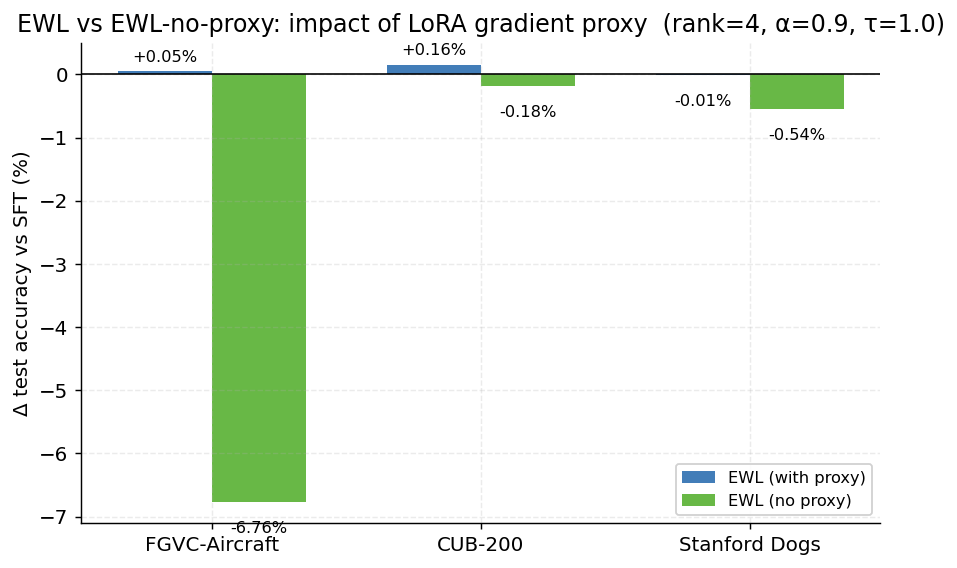

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for ds in DATASETS:
    vals = {}
    for cond in CONDITIONS:
        subset = df[(df.dataset == ds) & (df.condition == cond)]["test_acc"].dropna()
        vals[cond] = subset.mean() if len(subset) else np.nan

    # Plot delta bars: ewl vs baseline, ewl_no_proxy vs baseline
    delta_ewl = (vals.get("ewl", np.nan) - vals.get("baseline", np.nan)) * 100
    delta_proxy = (vals.get("ewl_no_proxy", np.nan) - vals.get("baseline", np.nan)) * 100
    label = DS_LABELS.get(ds, ds)
    print(f"{label}: EWL Δ={delta_ewl:+.2f}%  EWL-no-proxy Δ={delta_proxy:+.2f}%")

datasets_plot = DATASETS
xs2 = np.arange(len(datasets_plot))
w2 = 0.35

deltas_ewl, deltas_proxy = [], []
for ds in datasets_plot:
    b = df[(df.dataset == ds) & (df.condition == "baseline")]["test_acc"].mean()
    e = df[(df.dataset == ds) & (df.condition == "ewl")]["test_acc"].mean()
    p = df[(df.dataset == ds) & (df.condition == "ewl_no_proxy")]["test_acc"].mean()
    deltas_ewl.append((e - b) * 100)
    deltas_proxy.append((p - b) * 100)

bars_e = ax.bar(xs2 - w2/2, deltas_ewl, w2,
                color=C["ewl"], alpha=0.85, label="EWL (with proxy)")
bars_p = ax.bar(xs2 + w2/2, deltas_proxy, w2,
                color=C["ewl_no_proxy"], alpha=0.85, label="EWL (no proxy)")

for bar, v in zip(bars_e, deltas_ewl):
    ax.text(bar.get_x() + bar.get_width()/2, v + (0.1 if v >= 0 else -0.3),
            f"{v:+.2f}%", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
for bar, v in zip(bars_p, deltas_proxy):
    ax.text(bar.get_x() + bar.get_width()/2, v + (0.1 if v >= 0 else -0.3),
            f"{v:+.2f}%", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)

ax.axhline(0, color="black", lw=0.9)
ax.set_xticks(xs2)
ax.set_xticklabels([DS_LABELS.get(ds, ds) for ds in datasets_plot])
ax.set_ylabel("Δ test accuracy vs SFT (%)")
ax.set_title("EWL vs EWL-no-proxy: impact of LoRA gradient proxy  (rank=4, α=0.9, τ=1.0)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_proxy_ablation_delta.pdf", bbox_inches="tight", dpi=1200)
plt.show()
